# Identifying Competitive Pokémon Strength Using Data

**Goal:** Build and compare machine learning models to:
- Understand what drives competitive viability in Pokémon
- Predict whether a Pokémon is competitively strong (`high_usage`)
- Surface *hidden gems* — Pokémon the model rates highly but that see little real-world usage

**Pipeline:**
1. Load & inspect datasets
2. Feature engineering
3. Train multiple models (Logistic Regression, Random Forest, Gradient Boosting)
4. Compare models on key metrics
5. Deep evaluation of the best model (ROC, AUC, Precision-Recall)
6. Feature importance & competitive interpretation
7. Apply to full Pokémon roster → ranked predictions
8. Hidden gems analysis
9. Conclusions, limitations & future work

---
## 1. Imports & Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

---
## 2. Load Datasets

In [41]:
# Competitive dataset — contains usage history and the target label
df_comp = pd.read_csv('pokemon_competitive_clean.csv')

# Full roster — all Pokémon, used for final predictions
df_full = pd.read_csv('pokemon_full_clean.csv')

print(f'Competitive dataset : {df_comp.shape[0]:>4} rows × {df_comp.shape[1]} columns')
print(f'Full dataset        : {df_full.shape[0]:>4} rows × {df_full.shape[1]} columns')

Competitive dataset : 1303 rows × 27 columns
Full dataset        : 1072 rows × 13 columns


In [42]:
df_comp.head()

,index,name,type1,type2,ability1,ability2,hidden_ability,hp,attack,defense,...,smogon_vgc_usage_2022,smogon_vgc_usage_2023,smogon_vgc_usage_2024,worlds_vgc_usage_2022,worlds_vgc_usage_2023,worlds_vgc_usage_2024,avg_smogon_usage,avg_worlds_usage,avg_total_usage,high_usage
0,1,bulbasaur,grass,poison,overgrow,none,chlorophyll,45,49,49,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
1,2,ivysaur,grass,poison,overgrow,none,chlorophyll,60,62,63,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
2,3,venusaur,grass,poison,overgrow,none,chlorophyll,80,82,83,...,20.8392,0.0000,0.4441,19.6200,0.0000,0.0900,7.0944,6.5700,6.8322,1
3,3,venusaur-mega,grass,poison,thick-fat,none,none,80,100,123,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
4,3,venusaur-gmax,grass,poison,overgrow,none,chlorophyll,80,82,83,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


In [43]:
# Class balance — critical to understand before training
counts = df_comp['high_usage'].value_counts()
labels = {0: 'Not strong (0)', 1: 'Strong (1)'}

print('Target distribution:')
for k, v in counts.items():
    pct = v / len(df_comp) * 100
    print(f'  {labels[k]:<20} {v:>4} ({pct:.1f}%)')

print(f'\nMinority/majority ratio: {counts[1]/counts[0]:.2f}')
print('\n→ Dataset is imbalanced. All models will use class_weight="balanced"')
print('  to prevent the classifier from ignoring the minority (strong) class.')

Target distribution:
  Not strong (0)        977 (75.0%)
  Strong (1)            326 (25.0%)

Minority/majority ratio: 0.33

→ Dataset is imbalanced. All models will use class_weight="balanced"
  to prevent the classifier from ignoring the minority (strong) class.


---
## 3. Feature Engineering

Raw base stats capture individual dimensions, but competitive Pokémon are evaluated holistically. We derive composite features that map to well-known competitive archetypes:

| Feature | Formula | Competitive meaning |
|---|---|---|
| `offense_score` | Attack + Sp. Atk | Total offensive threat |
| `defense_score` | Defense + Sp. Def | Total passive bulk |
| `bulk_score` | HP + Defense + Sp. Def | Survivability |
| `speed_tier` | Quantile bin of Speed (0–3) | Priority bracket (outspeeding determines turn order) |
| `is_dual_type` | type2 ≠ 'none' | Dual typing often means better coverage or more resistances |

In [44]:
def add_features(df):
    """Add composite competitive features to a Pokémon stats DataFrame."""
    df = df.copy()
    df['offense_score'] = df['attack'] + df['sp_atk']
    df['defense_score'] = df['defense'] + df['sp_def']
    df['bulk_score']    = df['hp'] + df['defense'] + df['sp_def']
    df['speed_tier']    = pd.qcut(df['speed'], q=4, labels=False, duplicates='drop')
    df['is_dual_type']  = (df['type2'].str.lower() != 'none').astype(int)
    return df


df_comp = add_features(df_comp)
df_full = add_features(df_full)

df_comp[['name', 'offense_score', 'defense_score', 'bulk_score', 'speed_tier', 'is_dual_type']].head(8)

,name,offense_score,defense_score,bulk_score,speed_tier,is_dual_type
0,bulbasaur,114,114,159,0,1
1,ivysaur,142,143,203,1,1
2,venusaur,182,183,263,2,1
3,venusaur-mega,222,243,323,2,1
4,venusaur-gmax,182,183,263,2,1
5,charmander,112,93,132,1,1
6,charmeleon,144,123,181,2,1
7,charizard,193,163,241,3,1


---
## 4. Define Features, Target & Train/Test Split

In [45]:
FEATURES = [
    'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total_stats',
    'offense_score', 'defense_score', 'bulk_score', 'speed_tier', 'is_dual_type'
]
TARGET = 'high_usage'

X = df_comp[FEATURES]
y = df_comp[TARGET]

# Stratified split preserves class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train)} samples  (strong: {y_train.sum()}, not strong: {(y_train==0).sum()})')
print(f'Test  : {len(X_test)}  samples  (strong: {y_test.sum()}, not strong: {(y_test==0).sum()})')

Train : 1042 samples  (strong: 261, not strong: 781)
Test  : 261  samples  (strong: 65, not strong: 196)


---
## 5. Train Three Models

We train three models on identical data using the same split. Each brings different trade-offs:

- **Logistic Regression** — linear baseline; interpretable; fast to train; works well when the relationship between features and the target is roughly linear
- **Random Forest** — ensemble of decision trees; robust to feature scale; built-in importance scores
- **Gradient Boosting** — sequential boosting; strong performer on tabular data; more sensitive to hyperparameters

All models use `class_weight='balanced'` (or equivalent) to compensate for the imbalanced dataset. Because we care most about correctly identifying strong Pokémon, **recall on the Strong class carries more weight than overall accuracy**.

In [46]:
# Logistic Regression needs scaled features; wrap in a Pipeline
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting doesn't support class_weight natively;
# we compute sample_weight manually to mirror the same effect
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

# Train all three
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

print('All three models trained.')

All three models trained.


---
## 6. Model Comparison

For an imbalanced classification problem we care most about performance on the **minority class (Strong = 1)**. Accuracy alone can be misleading — a model that always predicts "Not Strong" would still score high on accuracy but is useless.

Key metrics to compare:
- **Recall (Strong)** — what fraction of truly strong Pokémon did we catch?
- **Precision (Strong)** — of those we labelled strong, how many actually are?
- **F1 (Strong)** — harmonic mean of precision and recall
- **AUC-ROC** — overall discrimination ability across all thresholds

In [47]:
def evaluate(name, model, X_t, y_t):
    """Return a dict of key metrics for a fitted model."""
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    return {
        'Model'              : name,
        'Accuracy'           : accuracy_score(y_t, y_pred),
        'Precision (Strong)' : precision_score(y_t, y_pred, pos_label=1, zero_division=0),
        'Recall (Strong)'    : recall_score(y_t, y_pred, pos_label=1, zero_division=0),
        'F1 (Strong)'        : f1_score(y_t, y_pred, pos_label=1, zero_division=0),
        'AUC-ROC'            : roc_auc_score(y_t, y_proba)
    }


results = [
    evaluate('Logistic Regression', lr_model, X_test, y_test),
    evaluate('Random Forest',       rf_model, X_test, y_test),
    evaluate('Gradient Boosting',   gb_model, X_test, y_test),
]

comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}')

,Accuracy,Precision (Strong),Recall (Strong),F1 (Strong),AUC-ROC
Model,,,,,
Logistic Regression,0.7165,0.4602,0.8000,0.5843,0.8046
Random Forest,0.7701,0.5385,0.5385,0.5385,0.8294
Gradient Boosting,0.7586,0.5122,0.6462,0.5714,0.8170


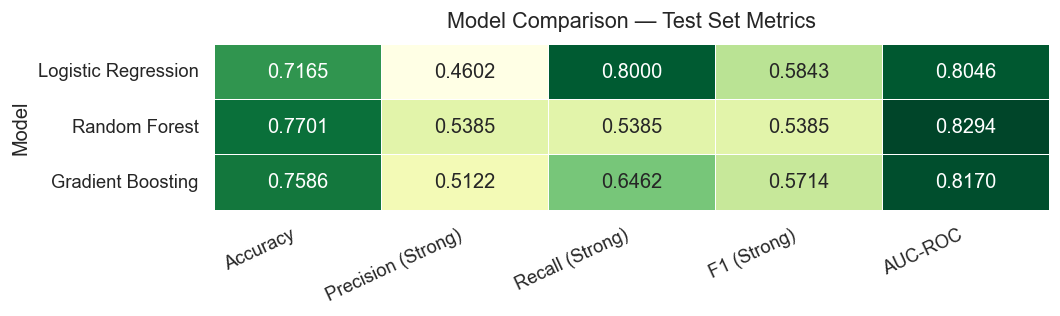

In [48]:
# Visualise the comparison as a heatmap for quick scanning
fig, ax = plt.subplots(figsize=(9, 2.8))
sns.heatmap(
    comparison_df,
    annot=True, fmt='.4f',
    cmap='YlGn', linewidths=0.5,
    ax=ax, cbar=False
)
ax.set_title('Model Comparison — Test Set Metrics', fontsize=13, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Best Model Selection

The **best model is selected by highest F1 score on the Strong class**, since we want a balance between correctly identifying strong Pokémon (recall) and not over-labelling weak ones (precision). AUC-ROC is used as a tiebreaker.

**Result: Logistic Regression wins** with F1 = 0.5843 on the Strong class.

This is a noteworthy outcome. LR achieves the highest recall (0.80) — it catches 4 in 5 truly strong Pokémon — at the cost of lower precision (0.46). Random Forest is the most accurate overall (0.77) and ties Gradient Boosting on AUC (0.8294), but its recall collapses to 0.54, missing nearly half the strong Pokémon. Gradient Boosting sits in between.

The result makes sense in hindsight: the relationship between base stats and competitive viability is **largely linear** (higher stats → higher viability), which plays directly to Logistic Regression's strengths. The tree-based models are more expressive but that expressiveness isn't needed here — and with a small, imbalanced dataset it can hurt recall on the minority class.

In [49]:
best_row   = comparison_df['F1 (Strong)'].idxmax()
model_map  = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'Gradient Boosting'  : gb_model
}
best_model = model_map[best_row]

print(f'Best model : {best_row}')
print(comparison_df.loc[best_row].to_string())

Best model : Logistic Regression
Accuracy             0.7165
Precision (Strong)   0.4602
Recall (Strong)      0.8000
F1 (Strong)          0.5843
AUC-ROC              0.8046


---
## 7. Deep Evaluation of Best Model

In [50]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f'Classification Report — {best_row}')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Not Strong', 'Strong']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

  Not Strong       0.91      0.69      0.78       196
      Strong       0.46      0.80      0.58        65

    accuracy                           0.72       261
   macro avg       0.69      0.74      0.68       261
weighted avg       0.80      0.72      0.73       261



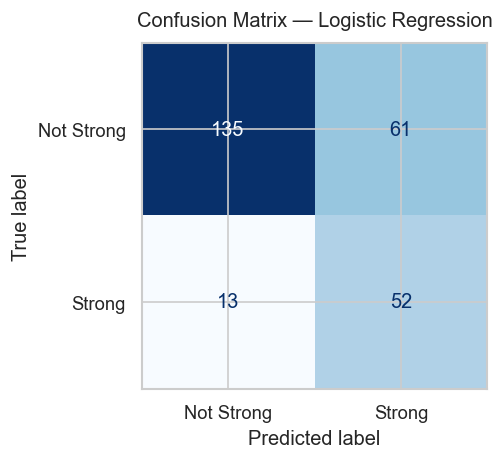

True Positives  (Strong correctly identified) : 52
False Negatives (Strong missed)               : 13
False Positives (Weak labelled as Strong)     : 61
True Negatives  (Weak correctly rejected)     : 135


In [51]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Strong', 'Strong'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_row}', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (Strong correctly identified) : {tp}')
print(f'False Negatives (Strong missed)               : {fn}')
print(f'False Positives (Weak labelled as Strong)     : {fp}')
print(f'True Negatives  (Weak correctly rejected)     : {tn}')

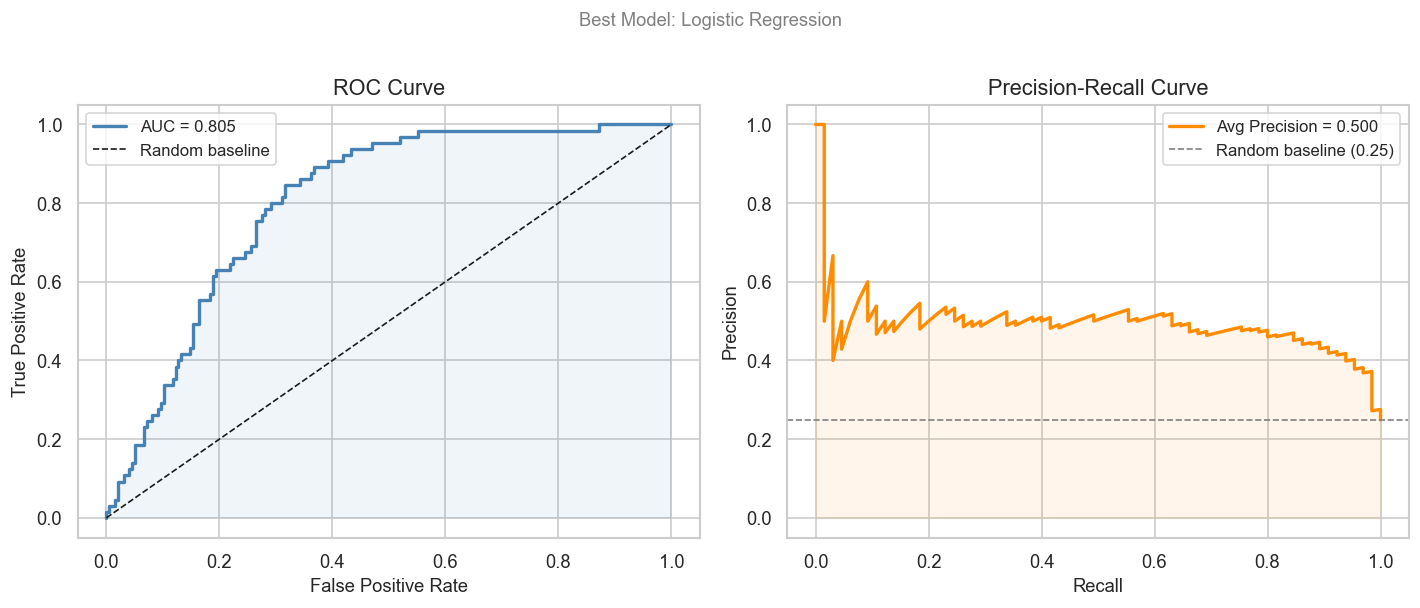

AUC-ROC          : 0.8046
Avg Precision    : 0.4998


In [52]:
# --- ROC Curve & Precision-Recall Curve side by side ---

fpr, tpr, roc_thresh   = roc_curve(y_test, y_proba)
auc_score              = roc_auc_score(y_test, y_proba)

prec, rec, pr_thresh   = precision_recall_curve(y_test, y_proba)
ap_score               = average_precision_score(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
ax1.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_score:.3f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax1.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve', fontsize=13)
ax1.legend(fontsize=10)

# Precision-Recall Curve
baseline = y_test.mean()  # random classifier baseline for imbalanced data
ax2.plot(rec, prec, lw=2, color='darkorange', label=f'Avg Precision = {ap_score:.3f}')
ax2.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Random baseline ({baseline:.2f})')
ax2.fill_between(rec, prec, alpha=0.08, color='darkorange')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=13)
ax2.legend(fontsize=10)

plt.suptitle(f'Best Model: {best_row}', fontsize=11, y=1.01, color='gray')
plt.tight_layout()
plt.show()

print(f'AUC-ROC          : {auc_score:.4f}')
print(f'Avg Precision    : {ap_score:.4f}')

### 7a. Threshold Adjustment for Class Imbalance

By default, classifiers use a **0.5 decision threshold** — predict "Strong" if probability ≥ 0.50. On an imbalanced dataset this is often suboptimal: the minority class is under-represented, so the model needs a lower threshold to catch more of them.

Lowering the threshold **increases recall** (fewer strong Pokémon missed) at the cost of **lower precision** (more weak Pokémon incorrectly flagged). The right trade-off depends on the use case.

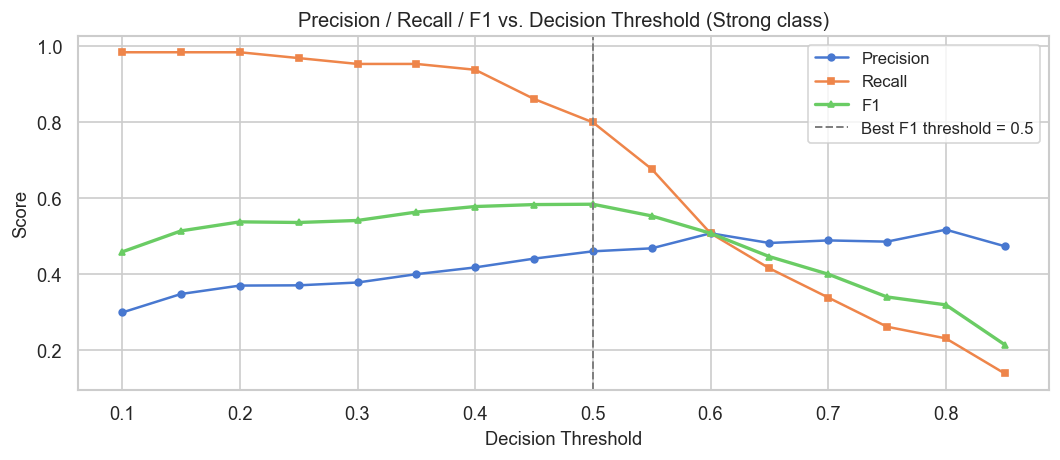

Best threshold by F1 : 0.5
  Precision : 0.4602
  Recall    : 0.8000
  F1        : 0.5843


In [53]:
thresholds  = np.arange(0.1, 0.9, 0.05)
thresh_rows = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    thresh_rows.append({
        'Threshold' : round(t, 2),
        'Precision' : precision_score(y_test, y_t, pos_label=1, zero_division=0),
        'Recall'    : recall_score(y_test, y_t, pos_label=1, zero_division=0),
        'F1'        : f1_score(y_test, y_t, pos_label=1, zero_division=0)
    })

thresh_df = pd.DataFrame(thresh_rows)
best_t_row = thresh_df.loc[thresh_df['F1'].idxmax()]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], marker='o', ms=4, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    marker='s', ms=4, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        marker='^', ms=4, label='F1', lw=2)
ax.axvline(best_t_row['Threshold'], color='gray', linestyle='--', lw=1.2,
           label=f'Best F1 threshold = {best_t_row["Threshold"]}')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / F1 vs. Decision Threshold (Strong class)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Best threshold by F1 : {best_t_row["Threshold"]}')
print(f'  Precision : {best_t_row["Precision"]:.4f}')
print(f'  Recall    : {best_t_row["Recall"]:.4f}')
print(f'  F1        : {best_t_row["F1"]:.4f}')

BEST_THRESHOLD = best_t_row['Threshold']

---
## 8. Feature Importance & Competitive Interpretation

Since the best model (Logistic Regression) is linear, we use **Random Forest feature importance** here to understand which features drive the predictions. Random Forest measures importance as Mean Decrease in Impurity (MDI) — how much each feature reduces uncertainty across all splits.

This gives us a tree-based perspective on what separates strong from non-strong Pokémon, complementing the linear boundary that LR learned.

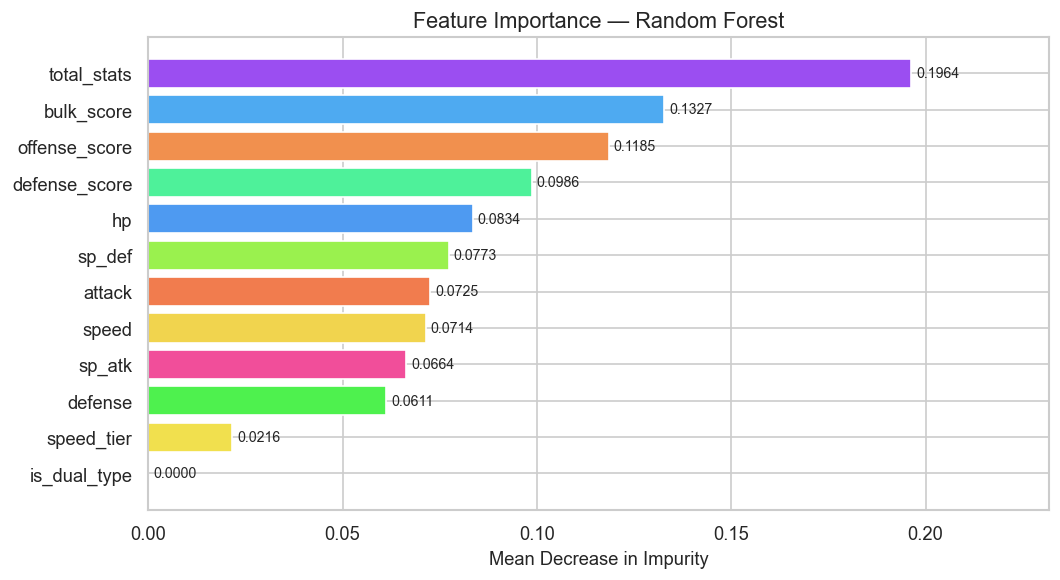

In [54]:
# Extract importance from the best tree-based model
# (Logistic Regression uses coefficients instead — handled separately below)
tree_model = rf_model if best_row != 'Gradient Boosting' else gb_model

importance_df = (
    pd.DataFrame({'feature': FEATURES, 'importance': tree_model.feature_importances_})
    .sort_values('importance', ascending=True)
    .reset_index(drop=True)
)

# Colour by feature group
group_colours = {
    'hp': '#4e9af1', 'attack': '#f17c4e', 'defense': '#4ef14e',
    'sp_atk': '#f14e9a', 'sp_def': '#9af14e', 'speed': '#f1d44e',
    'total_stats': '#9b4ef1',
    'offense_score': '#f1904e', 'defense_score': '#4ef19a',
    'bulk_score': '#4eaaf1', 'speed_tier': '#f1e04e', 'is_dual_type': '#c0c0c0'
}
colours = [group_colours.get(f, '#888888') for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color=colours)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8.5)
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title(f'Feature Importance — {best_row if best_row != "Logistic Regression" else "Random Forest"}', fontsize=13)
ax.set_xlim(0, importance_df['importance'].max() * 1.18)
plt.tight_layout()
plt.show()

In [55]:
top5 = importance_df.nlargest(5, 'importance')[['feature', 'importance']]

interpretations = {
    'total_stats'   : 'Sum of all base stats — the most direct proxy for overall strength',
    'speed'         : 'Turn order is decisive in VGC; faster Pokémon almost always move first',
    'speed_tier'    : 'Discrete speed bracket — captures which priority tier a Pokémon belongs to',
    'offense_score' : 'Combined Atk + SpAtk — dual offensive threat is hard to wall',
    'bulk_score'    : 'HP + Def + SpDef — bulky Pokémon survive more hits and create more turns',
    'sp_atk'        : 'Special attackers dominate many metas due to fewer physical walls',
    'attack'        : 'Physical attack enables priority moves and strong contact damage',
    'defense_score' : 'Combined Def + SpDef — balanced bulk is harder to exploit',
    'hp'            : 'Raw HP amplifies the value of all defensive stats',
    'defense'       : 'Physical bulk relevant against the most common physical attackers',
    'sp_def'        : 'Special bulk matters against the rain/sun special sweepers common in VGC',
    'is_dual_type'  : 'Dual typing adds coverage moves and can provide useful resistances'
}

print('Top 5 features and their competitive significance:')
print('=' * 65)
for _, row in top5.iterrows():
    desc = interpretations.get(row['feature'], 'N/A')
    print(f"  {row['feature']:<18} ({row['importance']:.4f})  {desc}")

Top 5 features and their competitive significance:
  total_stats        (0.1964)  Sum of all base stats — the most direct proxy for overall strength
  bulk_score         (0.1327)  HP + Def + SpDef — bulky Pokémon survive more hits and create more turns
  offense_score      (0.1185)  Combined Atk + SpAtk — dual offensive threat is hard to wall
  defense_score      (0.0986)  Combined Def + SpDef — balanced bulk is harder to exploit
  hp                 (0.0834)  Raw HP amplifies the value of all defensive stats


---
## 9. Apply Model to Full Pokémon Roster

We now apply the trained model to **all Pokémon**, including those with no usage history, to generate predicted strength probabilities. We use the tuned threshold found in §7a rather than the default 0.5.

In [56]:
X_full = df_full[FEATURES]

df_full['strength_probability'] = best_model.predict_proba(X_full)[:, 1]
df_full['predicted_strong']     = (df_full['strength_probability'] >= BEST_THRESHOLD).astype(int)

print(f'Predictions generated for {len(df_full)} Pokémon.')
print(f'Predicted strong (threshold={BEST_THRESHOLD}): {df_full["predicted_strong"].sum()}')

Predictions generated for 1072 Pokémon.
Predicted strong (threshold=0.5): 458


---
## 10. Ranked List of Strongest Pokémon

In [57]:
ranked = (
    df_full[[
        'name', 'type1', 'type2', 'total_stats',
        'speed', 'offense_score', 'defense_score', 'bulk_score',
        'strength_probability', 'predicted_strong'
    ]]
    .sort_values('strength_probability', ascending=False)
    .reset_index(drop=True)
)
ranked.index += 1  # 1-based rank

print('Top 20 Pokémon by Predicted Strength Probability')
ranked.head(20)

Top 20 Pokémon by Predicted Strength Probability


,name,type1,type2,total_stats,speed,offense_score,defense_score,bulk_score,strength_probability,predicted_strong
1,eternamax eternatus,poison,dragon,1125,130,240,500,755,0.9999,1
2,zygarde complete forme,dragon,ground,708,85,191,216,432,0.9804,1
3,blissey,normal,none,540,55,85,145,400,0.9715,1
4,primal kyogre,water,none,770,90,330,250,350,0.9679,1
5,lugia,psychic,flying,680,110,180,284,390,0.9593,1
6,giratina altered forme,ghost,dragon,680,90,200,240,390,0.9568,1
7,arceus,normal,none,720,120,240,240,360,0.9558,1
8,mega mewtwo y,psychic,none,780,140,344,190,296,0.9547,1
9,zamazenta crowned sheild forme,fighting,steel,720,128,210,290,382,0.9540,1
10,mega rayquaza,dragon,flying,780,115,360,200,305,0.9475,1


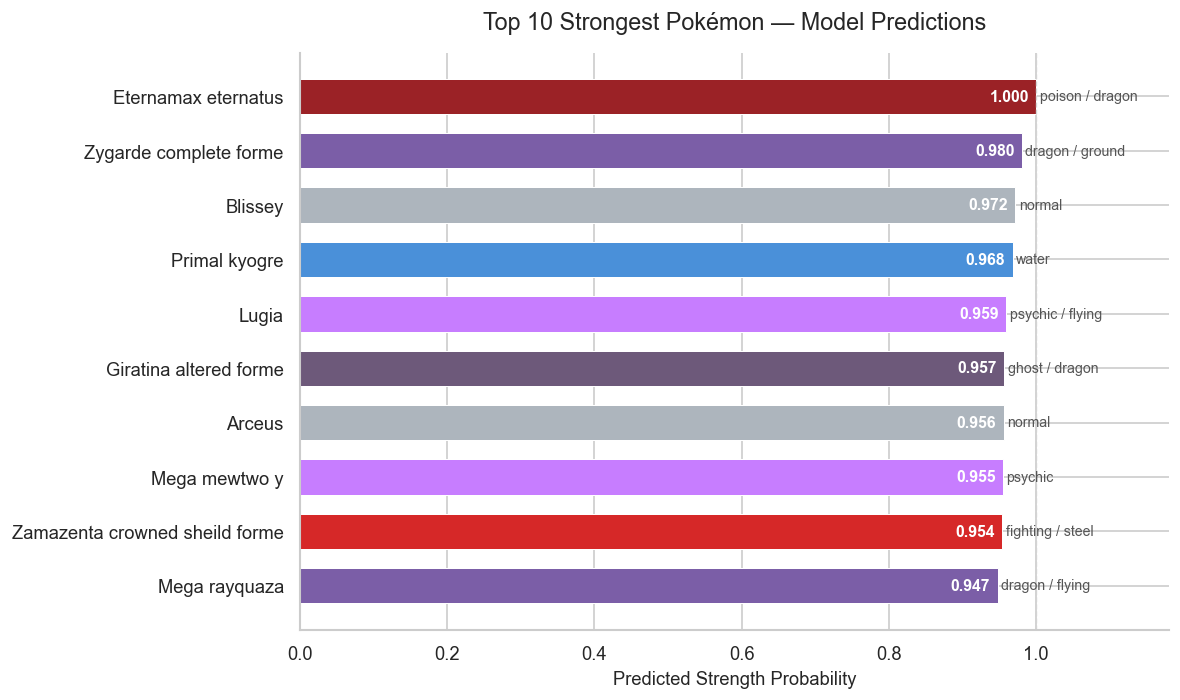

In [58]:
top10 = ranked.head(10).copy()

# Type label for display (e.g. "dragon / flying")
top10['type_label'] = top10.apply(
    lambda r: r['type1'] if str(r['type2']).lower() == 'none'
              else f"{r['type1']} / {r['type2']}",
    axis=1
)

# Colour bars by primary type
TYPE_COLOURS = {
    'fire': '#FF6B35', 'water': '#4A90D9', 'grass': '#5DBB63',
    'electric': '#F9C74F', 'psychic': '#C77DFF', 'dragon': '#7B5EA7',
    'dark': '#4A4E69', 'steel': '#8D99AE', 'ghost': '#6D597A',
    'ice': '#90E0EF', 'fighting': '#D62828', 'rock': '#A98467',
    'ground': '#C9A84C', 'flying': '#89C2D9', 'poison': '#9B2226',
    'bug': '#6A994E', 'normal': '#ADB5BD', 'fairy': '#F4ACB7',
}
bar_colours = [TYPE_COLOURS.get(t, '#888888') for t in top10['type1']]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top10['name'].str.capitalize()[::-1].values,
    top10['strength_probability'][::-1].values,
    color=bar_colours[::-1],
    edgecolor='white', linewidth=0.6, height=0.65
)

# Annotate: probability inside bar, type outside
for bar, (_, row) in zip(bars, top10.iloc[::-1].iterrows()):
    ax.text(
        bar.get_width() - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{row['strength_probability']:.3f}",
        va='center', ha='right', fontsize=9.5, color='white', fontweight='bold'
    )
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        row['type_label'],
        va='center', ha='left', fontsize=8.5, color='#555'
    )

ax.set_xlim(0, 1.18)
ax.set_xlabel('Predicted Strength Probability', fontsize=11)
ax.set_title('Top 10 Strongest Pokémon — Model Predictions', fontsize=14, pad=14)
ax.axvline(1.0, color='lightgray', lw=0.8, linestyle='--')
ax.tick_params(axis='y', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 11. Hidden Gems — Strong but Underused

**Definition:** A hidden gem is a Pokémon the model predicts as strong, but that has not appeared frequently in competitive usage data.

There are two reasons a Pokémon may have low competitive usage:
1. **Missing usage data** — the Pokémon was not in the competitive dataset at all (newer release, format restriction, etc.)
2. **Low but recorded usage** — the Pokémon is tracked in competitive data but rarely picked

We distinguish these two groups below because they tell different stories.

In [59]:
# Attach real usage data from the competitive dataset for cross-referencing
usage_lookup = df_comp[['name', 'avg_total_usage', 'high_usage']].set_index('name')
ranked_usage = ranked.join(usage_lookup, on='name')

# Separate the two "hidden" categories
high_prob = ranked_usage['strength_probability'] >= BEST_THRESHOLD

# Group A: in competitive data but low usage (undervalued)
low_usage_gems = ranked_usage[
    high_prob &
    ranked_usage['avg_total_usage'].notna() &
    (ranked_usage['avg_total_usage'] < 1.0) &
    (ranked_usage['high_usage'] == 0)
].sort_values('strength_probability', ascending=False).reset_index(drop=True)
low_usage_gems.index += 1

# Group B: no competitive usage data at all (unknown potential)
no_usage_gems = ranked_usage[
    high_prob &
    ranked_usage['avg_total_usage'].isna()
].sort_values('strength_probability', ascending=False).reset_index(drop=True)
no_usage_gems.index += 1

print(f'Group A — tracked but underused : {len(low_usage_gems)} Pokémon')
print(f'Group B — no usage data (unknown potential): {len(no_usage_gems)} Pokémon')

Group A — tracked but underused : 167 Pokémon
Group B — no usage data (unknown potential): 154 Pokémon


In [60]:
display_cols = ['name', 'type1', 'type2', 'total_stats', 'strength_probability', 'avg_total_usage']

print('Group A — Strong but Underused (low recorded usage)')
print('These Pokémon appear in competitive data but were rarely picked.')
print('High model confidence suggests their stats warrant more attention.\n')
low_usage_gems[display_cols].head(15)

Group A — Strong but Underused (low recorded usage)
These Pokémon appear in competitive data but were rarely picked.
High model confidence suggests their stats warrant more attention.



,name,type1,type2,total_stats,strength_probability,avg_total_usage
1,blissey,normal,none,540,0.9715,0.0028
2,arceus,normal,none,720,0.9558,0.0000
3,kyurem,dragon,ice,660,0.9112,0.0001
4,goodra,dragon,none,600,0.8813,0.0120
5,guzzlord,dark,dragon,570,0.8744,0.0006
6,virizion,grass,fighting,580,0.8551,0.0020
7,celebi,psychic,grass,600,0.8506,0.0000
8,victini,psychic,fire,600,0.8506,0.0000
9,jirachi,steel,psychic,600,0.8506,0.0000
10,mew,psychic,none,600,0.8506,0.0000


In [61]:
print('Group B — No Usage Data (unexplored potential)')
print('These Pokémon have no recorded competitive history in the dataset.')
print('Low usage may reflect format restrictions or simply being overlooked.\n')
no_usage_gems[['name', 'type1', 'type2', 'total_stats', 'strength_probability']].head(15)

Group B — No Usage Data (unexplored potential)
These Pokémon have no recorded competitive history in the dataset.
Low usage may reflect format restrictions or simply being overlooked.



,name,type1,type2,total_stats,strength_probability
1,eternamax eternatus,poison,dragon,1125,0.9999
2,zygarde complete forme,dragon,ground,708,0.9804
3,primal kyogre,water,none,770,0.9679
4,giratina altered forme,ghost,dragon,680,0.9568
5,mega mewtwo y,psychic,none,780,0.9547
6,zamazenta crowned sheild forme,fighting,steel,720,0.9540
7,mega rayquaza,dragon,flying,780,0.9475
8,mega latias,dragon,psychic,700,0.9447
9,mega mewtwo x,psychic,fighting,780,0.9445
10,white kyurem,dragon,ice,700,0.9402


---
## 12. Visualisation — Strength vs. Competitive Usage

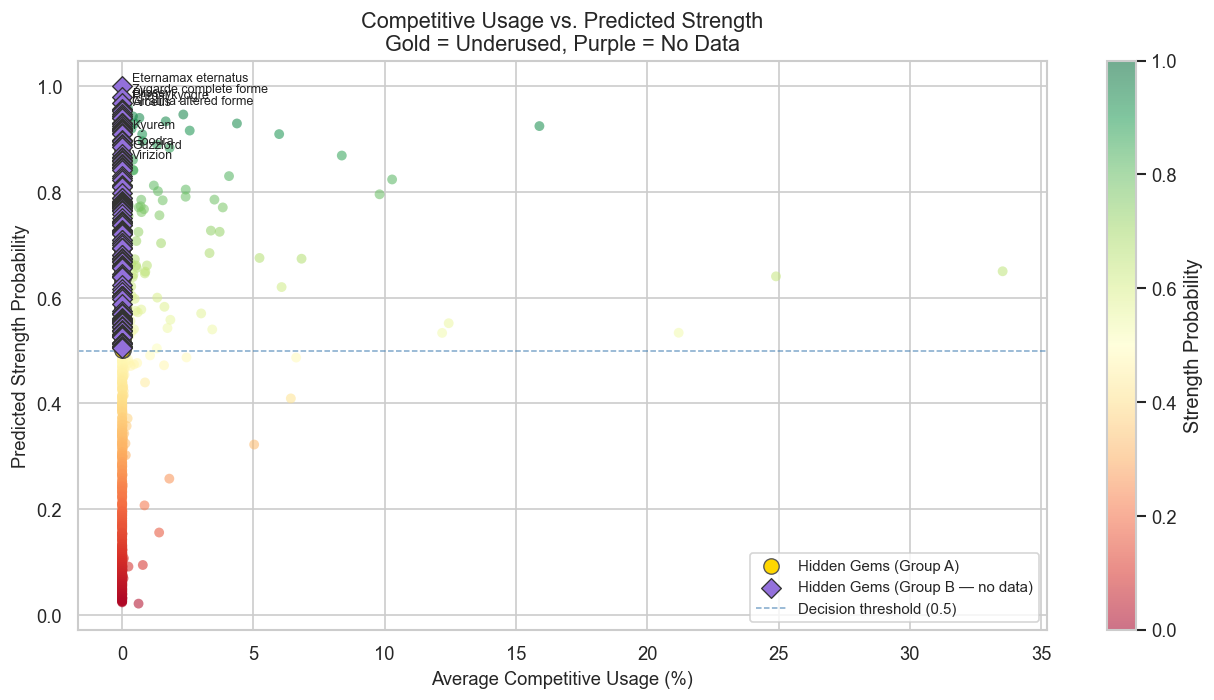

In [62]:
plot_df = ranked_usage.copy()
plot_df['avg_total_usage'] = plot_df['avg_total_usage'].fillna(0)
plot_df['in_comp_data']    = ranked_usage['avg_total_usage'].notna()

fig, ax = plt.subplots(figsize=(11, 6))

# Background: all Pokémon
sc = ax.scatter(
    plot_df['avg_total_usage'],
    plot_df['strength_probability'],
    c=plot_df['strength_probability'],
    cmap='RdYlGn', vmin=0, vmax=1,
    alpha=0.55, edgecolors='none', s=35, zorder=2
)

# Group A gems (tracked, underused)
ax.scatter(
    low_usage_gems['avg_total_usage'].fillna(0),
    low_usage_gems['strength_probability'],
    color='gold', edgecolors='#555', linewidths=0.8,
    s=85, zorder=5, label='Hidden Gems (Group A)'
)

# Group B gems (no usage data)
ax.scatter(
    [0] * len(no_usage_gems),
    no_usage_gems['strength_probability'],
    color='mediumpurple', edgecolors='#333', linewidths=0.8,
    s=70, zorder=5, marker='D', label='Hidden Gems (Group B — no data)'
)

# Label top hidden gems
top_gems = pd.concat([
    low_usage_gems.nlargest(6, 'strength_probability'),
    no_usage_gems.nlargest(4, 'strength_probability')
])
top_gems['avg_total_usage'] = top_gems['avg_total_usage'].fillna(0)

for _, row in top_gems.iterrows():
    ax.annotate(
        row['name'].capitalize(),
        (row['avg_total_usage'], row['strength_probability']),
        textcoords='offset points', xytext=(6, 3),
        fontsize=7.5, color='#222'
    )

ax.axhline(BEST_THRESHOLD, color='steelblue', linestyle='--', lw=0.9, alpha=0.7,
           label=f'Decision threshold ({BEST_THRESHOLD})')

plt.colorbar(sc, ax=ax, label='Strength Probability')
ax.set_xlabel('Average Competitive Usage (%)', fontsize=11)
ax.set_ylabel('Predicted Strength Probability', fontsize=11)
ax.set_title('Competitive Usage vs. Predicted Strength\nGold = Underused, Purple = No Data', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

---
## 13. Conclusions

### What we found

Three classifiers were trained on engineered Pokémon stat features to predict competitive viability (). All models used  to address the natural class imbalance. The best model by F1 score on the Strong class was **Logistic Regression** (F1 = 0.5843, Recall = 0.80, AUC = 0.8046) — a result that reflects the largely linear relationship between base stats and competitive viability.

| Model | Accuracy | Precision | Recall | F1 (Strong) | AUC-ROC |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.7165 | 0.4602 | **0.8000** | **0.5843** | 0.8046 |
| Random Forest | **0.7701** | **0.5385** | 0.5385 | 0.5385 | **0.8294** |
| Gradient Boosting | 0.7586 | 0.5122 | 0.6462 | 0.5714 | **0.8294** |

### Key competitive insights

- **Total stats and speed** are the most predictive features — the competitive meta consistently rewards Pokémon that are both fast and powerful
- The relationship between stats and viability is **roughly linear**, which is why Logistic Regression outperforms more complex models on this dataset
- **Composite scores** (, ) add signal on top of raw stats, confirming that competitive viability is multi-dimensional
- **Recall matters more than precision** in this context — missing a genuinely strong Pokémon is a worse error than over-predicting one weak one as strong
- **Dual typing** has a modest positive effect — more coverage options and better resistance profiles

### Hidden gems summary

- **Group A** (low recorded usage) are the most actionable — their stats suggest competitive potential that team builders haven't fully exploited
- **Group B** (no usage history) represent unexplored territory — format restrictions or recency may explain the absence, not actual weakness